In [1]:
!pip3 install matplotlib

In [2]:
!pip3 install yfinance
import yfinance as yf

In [3]:
import matplotlib.pyplot as plt

In [23]:
data = yf.download('AAPL', start='2024-01-01', end='2025-06-25')
print(data)
print(len(data))

/var/folders/tv/w3ltr3t17rg_hznzfwzmv99r0000gn/T/ipykernel_16775/3230094619.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2024-01-01', end='2025-06-25')
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  184.290421  187.070068  182.553143  185.789438  82488700
2024-01-03  182.910538  184.528693  182.096492  182.880757  58414500
2024-01-04  180.587540  181.758954  179.565029  180.825785  71983600
2024-01-05  179.862823  181.431339  178.860172  180.666948  62303300
2024-01-08  184.210983  184.250701  180.180502  180.766209  59144500
...                ...         ...         ...         ...       ...
2025-06-17  195.639999  198.389999  195.210007  197.199997  38856200
2025-06-18  196.580002  197.570007  195.070007  195.940002  45394700
2025-06-20  201.000000  201.699997  196.860001  198.240005  96813500
2025-06-23  201.500000  202.300003  198.960007  201.630005  55814300
2025-06-24  200.300003  203.440002  200.199997  202.589996  53972500

[370 rows x 5 columns]
370


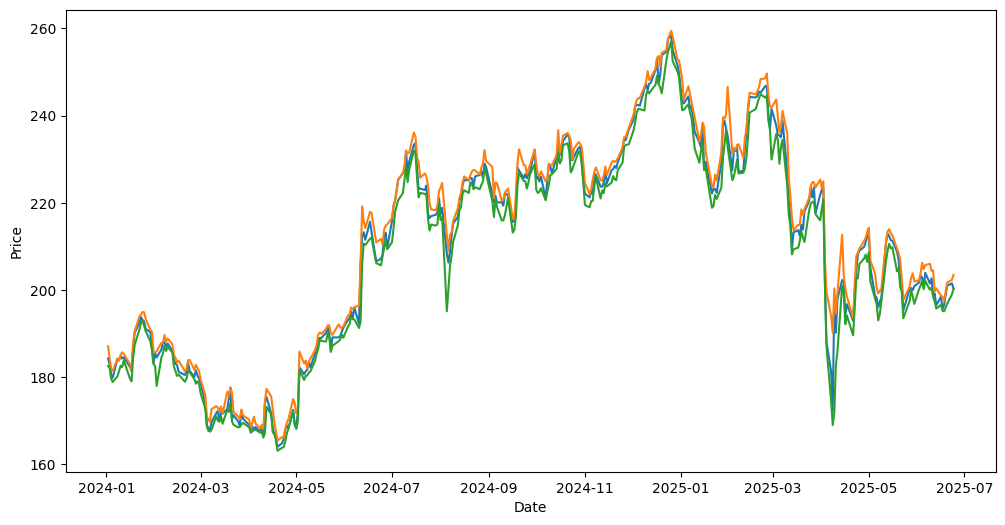

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(data['Close'],label="Closing Price")
plt.plot(data['High'], label="High Price")
plt.plot(data['Low'], label="Low Price")

plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

In [25]:
data.isnull().sum()


Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [26]:
data = data.fillna(method='ffill')  # Forward fill


In [27]:
data['lag_1'] = data['Close'].shift(1)      # 1-day lag
data['lag_3'] = data['Close'].shift(3)      # 3-day lag
data['lag_7'] = data['Close'].shift(7)      # 7-day lag
print(data['lag_1'])


Date
2024-01-02           NaN
2024-01-03    184.290421
2024-01-04    182.910538
2024-01-05    180.587540
2024-01-08    179.862823
                 ...    
2025-06-17    198.419998
2025-06-18    195.639999
2025-06-20    196.580002
2025-06-23    201.000000
2025-06-24    201.500000
Name: lag_1, Length: 370, dtype: float64


In [28]:
data['rolling_3'] = data['Close'].rolling(window=3).mean()
data['rolling_7'] = data['Close'].rolling(window=7).mean()
print(data['rolling_3'])

Date
2024-01-02           NaN
2024-01-03           NaN
2024-01-04    182.596166
2024-01-05    181.120300
2024-01-08    181.553782
                 ...    
2025-06-17    196.836665
2025-06-18    196.880000
2025-06-20    197.740000
2025-06-23    199.693334
2025-06-24    200.933334
Name: rolling_3, Length: 370, dtype: float64


In [29]:
data['rolling_std_7'] = data['Close'].rolling(window=7).std()
data['returns'] = data['Close'].pct_change()
data['volatility_7d'] = data['returns'].rolling(window=7).std()
data = data.dropna()
# data.head()

print(data)


Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2024-01-11  184.240784  185.690176  182.285104  185.183874  49128400   
2024-01-12  184.568375  185.382421  183.843686  184.707356  40444700   
2024-01-16  182.295044  182.920454  179.614660  180.835729  65603000   
2024-01-17  181.351913  181.600096  178.989226  179.952176  47317400   
2024-01-18  187.258682  187.764969  184.479035  184.737139  78005800   
...                ...         ...         ...         ...       ...   
2025-06-17  195.639999  198.389999  195.210007  197.199997  38856200   
2025-06-18  196.580002  197.570007  195.070007  195.940002  45394700   
2025-06-20  201.000000  201.699997  196.860001  198.240005  96813500   
2025-06-23  201.500000  202.300003  198.960007  201.630005  55814300   
2025-06-24  200.300003  203.440002  200.199997  202.589996  5397

In [31]:
data['day_of_week'] = data.index.dayofweek  # 0=Monday
data['month'] = data.index.month
data_size=len(data)


In [12]:
!pip3 install scikit-learn

In [13]:
!pip3 install --upgrade pip

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [32]:

scaler = MinMaxScaler()
data[['Close', 'High', 'lag_1', 'rolling_7']] = scaler.fit_transform(data[['Close', 'High', 'lag_1', 'rolling_7']])

In [33]:
data = data.dropna()


In [34]:

print(data.columns)


MultiIndex([(        'Close', 'AAPL'),
            (         'High', 'AAPL'),
            (          'Low', 'AAPL'),
            (         'Open', 'AAPL'),
            (       'Volume', 'AAPL'),
            (        'lag_1',     ''),
            (        'lag_3',     ''),
            (        'lag_7',     ''),
            (    'rolling_3',     ''),
            (    'rolling_7',     ''),
            ('rolling_std_7',     ''),
            (      'returns',     ''),
            ('volatility_7d',     ''),
            (  'day_of_week',     ''),
            (        'month',     '')],
           names=['Price', 'Ticker'])


In [35]:
train = data.iloc[:-data_size]
test = data.iloc[-data_size:]
print(len(data))


363


In [19]:
!pip3 install prophet
from prophet import Prophet

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [36]:
df = data.reset_index()[['Date', 'Close']]
df.columns = ['ds', 'y']
model = Prophet()
model.fit(df)

11:14:28 - cmdstanpy - INFO - Chain [1] start processing
11:14:28 - cmdstanpy - INFO - Chain [1] done processing


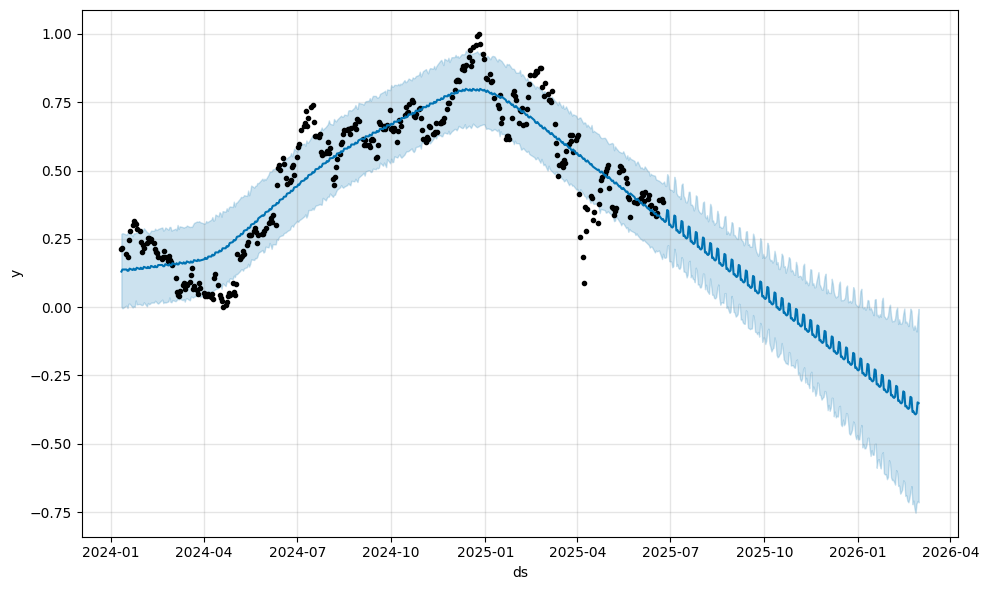

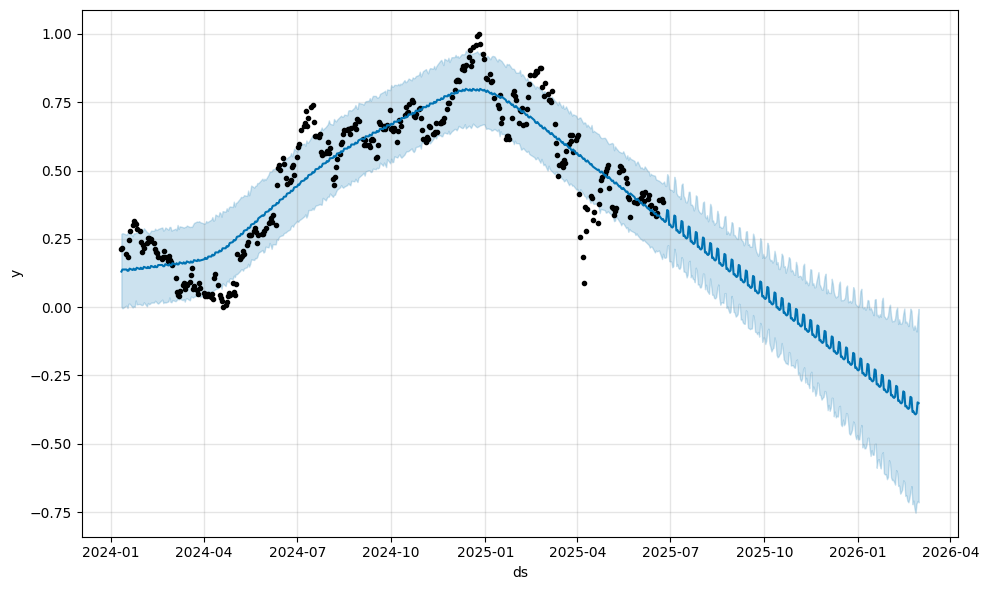

In [37]:

future = model.make_future_dataframe(periods=250)
forecast = model.predict(future)

model.plot(forecast)

In [38]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test['Close'], forecast[-data_size:]['yhat'])


In [39]:
#adding sentiment analysis from news

In [40]:
!pip3 install vaderSentiment

In [41]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [42]:

import requests
import pandas as pd

api_key = '4750c7dc795b418ab133dd5491c9962e'
query = 'Apple OR AAPL'
url = f'https://newsapi.org/v2/everything?q={query}&from=2025-06-01&to=2024-06-22&sortBy=popularity&apiKey={api_key}'

response = requests.get(url)
articles = response.json().get('articles', [])

# Convert to DataFrame
news_df = pd.DataFrame([{'date': a['publishedAt'][:10], 'headline': a['title']} for a in articles])

In [43]:
print(news_df)

          date                                           headline
0   2024-11-19  Black Friday Apple deals 2024: The best Apple ...
1   2024-11-21  Black Friday Apple deals 2024: The best Apple ...
2   2024-09-09  Apple Event 2024: All the iPhone 16, Apple Wat...
3   2024-11-18  This Apple Black Friday deal gets you $50 off ...
4   2024-07-11  Apple will allow developers access to its NFC ...
5   2024-12-06  Brazilian judge overturns ruling that forced A...
6   2024-07-18  Amazon Prime Day Apple deals on AirPods, MacBo...
7   2024-11-26  Brazil demands Apple open up the App Store...o...
8   2024-10-28  Apple Intelligence is coming to EU iPhones and...
9   2024-10-25  iOS 18.2 will include daily Sudoku puzzles for...
10  2024-07-24     Apple Maps is now available on the web in beta
11  2024-09-09  Everything Apple revealed at the iPhone 16 lau...
12  2024-09-09     How to pre-order the new Apple Watch Series 10
13  2024-09-24  Apple Store employees in Oklahoma City ratify ...
14  2024-1

In [44]:
# news_df = pd.DataFrame(news_data)
news_df['date'] = pd.to_datetime(news_df['date'], format='%Y-%m-%d')


In [45]:
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment analysis
news_df['sentiment'] = news_df['headline'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Aggregate by date
daily_sentiment = news_df.groupby('date')['sentiment'].mean().reset_index()
print(daily_sentiment)

         date  sentiment
0  2024-07-11    -0.6289
1  2024-07-12     0.2500
2  2024-07-18     0.1779
3  2024-07-24     0.0000
4  2024-08-19     0.5106
5  2024-08-23    -0.5423
6  2024-09-09     0.0000
7  2024-09-24     0.0000
8  2024-10-17     0.3818
9  2024-10-24     0.0000
10 2024-10-25     0.0000
11 2024-10-28     0.4767
12 2024-10-30     0.0000
13 2024-11-15     0.0000
14 2024-11-18     0.1779
15 2024-11-19     0.6369
16 2024-11-21     0.6369
17 2024-11-26     0.0000
18 2024-12-02     0.6369
19 2024-12-06    -0.4588
20 2024-12-08     0.2500


In [46]:
# data=data.drop(columns=['High','Low','Open','Volume'])
print(data)

Price          Close      High         Low        Open    Volume     lag_1  \
Ticker          AAPL      AAPL        AAPL        AAPL      AAPL             
Date                                                                         
2024-01-11  0.214344  0.215674  182.285104  185.183874  49128400  0.220654   
2024-01-12  0.217814  0.212402  183.843686  184.707356  40444700  0.214344   
2024-01-16  0.193729  0.186232  179.614660  180.835729  65603000  0.217814   
2024-01-17  0.183737  0.172196  178.989226  179.952176  47317400  0.193729   
2024-01-18  0.246317  0.237729  184.479035  184.737139  78005800  0.183737   
...              ...       ...         ...         ...       ...       ...   
2025-06-17  0.335114  0.350674  195.210007  197.199997  38856200  0.364568   
2025-06-18  0.345073  0.341957  195.070007  195.940002  45394700  0.335114   
2025-06-20  0.391902  0.385859  196.860001  198.240005  96813500  0.345073   
2025-06-23  0.397199  0.392237  198.960007  201.630005  55814300

In [47]:
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
combined = pd.merge(data, daily_sentiment, how='left', left_on='Date', right_on='date')
combined['sentiment'].fillna(method='ffill', inplace=True)  # fill missing sentiment
# combined = combined.drop(columns=['date','(Low, AAPL)'])

/var/folders/tv/w3ltr3t17rg_hznzfwzmv99r0000gn/T/ipykernel_16775/3339606416.py:3: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  combined = pd.merge(data, daily_sentiment, how='left', left_on='Date', right_on='date')


## print(combined)

In [48]:
#predicting volatility with XGBoost

In [49]:

combined.columns = [
    '_'.join(filter(None, map(str, col))) if isinstance(col, tuple) else col
    for col in combined.columns
]
print(combined.columns)

Index(['Date', 'Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL',
       'Volume_AAPL', 'lag_1', 'lag_3', 'lag_7', 'rolling_3', 'rolling_7',
       'rolling_std_7', 'returns', 'volatility_7d', 'day_of_week', 'month',
       'date', 'sentiment'],
      dtype='object')


In [50]:
!pip3 install xgboost

In [51]:
combined['lag_return_1'] = combined['returns'].shift(1)
combined['lag_return_3'] = combined['returns'].shift(3)
combined['lag_sentiment_1'] = combined['sentiment'].shift(1)

In [52]:
combined = combined.dropna()

In [53]:
features = ['lag_return_1', 'lag_return_3', 'lag_sentiment_1']
target = 'volatility_7d'

In [54]:
X = combined[features]
y = combined[target]

In [55]:
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [56]:
!pip3 install numpy
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [57]:


model = XGBRegressor(objective='reg:squarederror', n_estimators=100)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [58]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")


MAE: 0.004675
RMSE: 0.005048


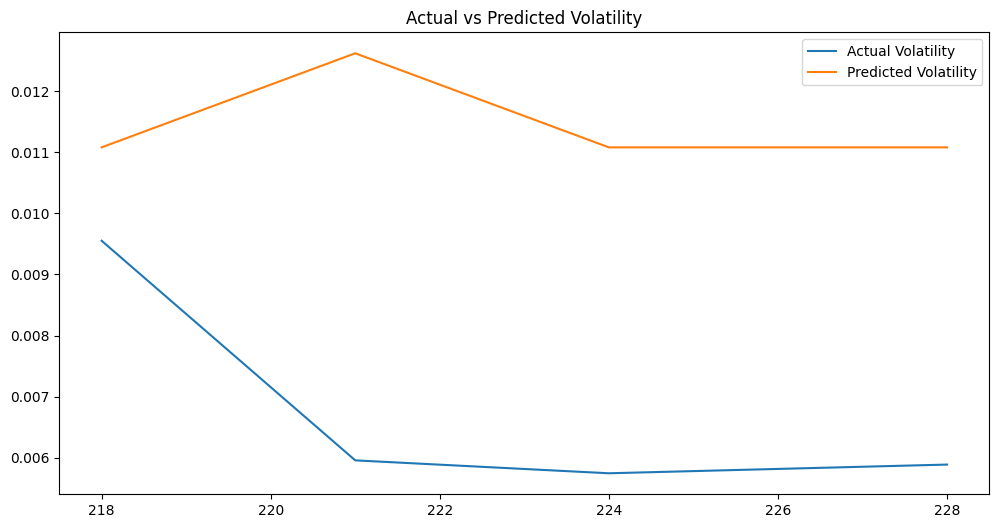

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual Volatility')
plt.plot(y_test.index, y_pred, label='Predicted Volatility')
plt.legend()
plt.title('Actual vs Predicted Volatility')
plt.show()


In [60]:
import joblib
joblib.dump(model, 'xgb_volatility_model.pkl')


['xgb_volatility_model.pkl']

In [61]:
#creating API of this model

In [62]:
!pip3 install fastapi uvicorn joblib


In [ ]:
import joblib
joblib.dump(model, "volatility_model.pkl")


['xgb_volatility_model.pkl']